# CST8509 Week 1: Introduction to Reinforcement Learning - Complete Demo

Demonstrates core RL concepts from Week 1:
- Agent-Environment interaction loop
- State, Action, Reward cycle
- Markov Property illustration
- Policy types (deterministic vs stochastic)
- Value Function estimation
- Q-Learning on Cliff Walking (simplified)
- Exploration vs Exploitation tradeoff

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv
from datetime import datetime

## Environment Setup

In [2]:
# ============================================================
# 环境配置
# Environment Setup
# ============================================================
load_dotenv('.env.local')
STUDENT_NAME = os.getenv('NAME', 'Peng Wang')
STUDENT_NUMBER = os.getenv('NUMBER', '041107730')

# 输出目录（保存可视化图片）
# Output directory for saving visualization images
SCRIPT_DIR = os.path.abspath('.')
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'week1_rl_intro_complete_demo_pages')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 随机种子（确保可复现）
# Random seed for reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 图表样式
# Plot style configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 60)
print(f"CST8509 Week 1: Introduction to Reinforcement Learning")
print(f"Author: {STUDENT_NAME} ({STUDENT_NUMBER})")
print(f"Date: {datetime.now().strftime('%Y-%m-%d')}")
print("=" * 60)

CST8509 Week 1: Introduction to Reinforcement Learning
Author: Peng Wang (041107730)
Date: 2026-02-26


## Step 1: Agent-Environment Interaction Loop Demo

In [3]:
# ============================================================
# 步骤 1：Agent-Environment 交互循环演示
# Step 1: Agent-Environment Interaction Loop Demo
# ============================================================
# 用一个简单的 4x4 网格世界演示 RL 的核心循环：
#   Agent 观察状态 → 选择动作 → 环境返回奖励和新状态
# Demonstrate the core RL loop with a simple 4x4 grid world:
#   Agent observes state → chooses action → environment returns reward and new state

GRID_SIZE = 4
GOAL_STATE = (3, 3)
START_STATE = (0, 0)

# 动作定义：上(0)、下(1)、左(2)、右(3)
# Action definitions: up(0), down(1), left(2), right(3)
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ACTION_NAMES = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}


def grid_step(state, action, grid_size=GRID_SIZE):
    """Execute one step in the grid world, return (next_state, reward, done)."""
    row, col = state
    dr, dc = ACTIONS[action]
    # 边界检查：超出网格则保持原位
    # Boundary check: stay in place if out of bounds
    new_row = max(0, min(grid_size - 1, row + dr))
    new_col = max(0, min(grid_size - 1, col + dc))
    next_state = (new_row, new_col)

    if next_state == GOAL_STATE:
        return next_state, 10, True   # 到达目标：+10 奖励 / Reach goal: +10 reward
    return next_state, -1, False      # 每步 -1 鼓励最短路径 / -1 per step encourages shortest path


# 演示一个完整的 episode（随机策略）
# Demonstrate a complete episode with random policy
print("\n" + "=" * 60)
print("Step 1: Agent-Environment Interaction Loop")
print("=" * 60)
print(f"Grid: {GRID_SIZE}x{GRID_SIZE}, Start: {START_STATE}, Goal: {GOAL_STATE}")
print(f"Reward: -1 per step, +10 at goal\n")

state = START_STATE
done = False
total_reward = 0
trajectory = [state]
step_count = 0
MAX_DEMO_STEPS = 15

print(f"{'Step':>4} | {'State':>8} | {'Action':>6} | {'Reward':>6} | {'Next State':>10}")
print("-" * 50)

while not done and step_count < MAX_DEMO_STEPS:
    action = random.choice(list(ACTIONS.keys()))
    next_state, reward, done = grid_step(state, action)
    total_reward += reward
    step_count += 1
    print(f"{step_count:>4} | {str(state):>8} | {ACTION_NAMES[action]:>6} | {reward:>6} | {str(next_state):>10}")
    state = next_state
    trajectory.append(state)

status = "REACHED GOAL" if done else f"STOPPED (max {MAX_DEMO_STEPS} steps)"
print(f"\nResult: {status}, Total reward: {total_reward}")


Step 1: Agent-Environment Interaction Loop
Grid: 4x4, Start: (0, 0), Goal: (3, 3)
Reward: -1 per step, +10 at goal

Step |    State | Action | Reward | Next State
--------------------------------------------------
   1 |   (0, 0) |     Up |     -1 |     (0, 0)
   2 |   (0, 0) |     Up |     -1 |     (0, 0)
   3 |   (0, 0) |   Left |     -1 |     (0, 0)
   4 |   (0, 0) |   Down |     -1 |     (1, 0)
   5 |   (1, 0) |   Down |     -1 |     (2, 0)
   6 |   (2, 0) |   Down |     -1 |     (3, 0)
   7 |   (3, 0) |     Up |     -1 |     (2, 0)
   8 |   (2, 0) |     Up |     -1 |     (1, 0)
   9 |   (1, 0) |  Right |     -1 |     (1, 1)
  10 |   (1, 1) |     Up |     -1 |     (0, 1)
  11 |   (0, 1) |     Up |     -1 |     (0, 1)
  12 |   (0, 1) |     Up |     -1 |     (0, 1)
  13 |   (0, 1) |   Down |     -1 |     (1, 1)
  14 |   (1, 1) |   Down |     -1 |     (2, 1)
  15 |   (2, 1) |     Up |     -1 |     (1, 1)

Result: STOPPED (max 15 steps), Total reward: -15


## Step 2: Markov Property Illustration

In [4]:
# ============================================================
# 步骤 2：马尔可夫性质演示
# Step 2: Markov Property Illustration
# ============================================================
# 演示"给定当前状态，未来与过去无关"
# Demonstrate "the future is independent of the past given the present"
# 两条不同的历史路径到达同一状态 → 未来转移概率相同
# Two different history paths reaching the same state → same future transition probabilities

print("\n" + "=" * 60)
print("Step 2: Markov Property Illustration")
print("=" * 60)

# 路径 A：(0,0) → (0,1) → (1,1)
# Path A: (0,0) → (0,1) → (1,1)
path_a = [(0, 0), (0, 1), (1, 1)]

# 路径 B：(0,0) → (1,0) → (1,1)
# Path B: (0,0) → (1,0) → (1,1)
path_b = [(0, 0), (1, 0), (1, 1)]

print(f"Path A history: {' -> '.join(str(s) for s in path_a)}")
print(f"Path B history: {' -> '.join(str(s) for s in path_b)}")
print(f"\nBoth arrive at state (1, 1)")
print(f"Markov Property: future transitions from (1,1) are IDENTICAL")
print(f"regardless of which path was taken to get here.\n")

# 从 (1,1) 出发，所有可能的下一状态
# From (1,1), all possible next states
current = (1, 1)
print(f"From state {current}, possible transitions:")
for action_id, action_name in ACTION_NAMES.items():
    next_s, reward, done = grid_step(current, action_id)
    print(f"  Action {action_name:>5} → State {next_s}, Reward = {reward}")


Step 2: Markov Property Illustration
Path A history: (0, 0) -> (0, 1) -> (1, 1)
Path B history: (0, 0) -> (1, 0) -> (1, 1)

Both arrive at state (1, 1)
Markov Property: future transitions from (1,1) are IDENTICAL
regardless of which path was taken to get here.

From state (1, 1), possible transitions:
  Action    Up → State (0, 1), Reward = -1
  Action  Down → State (2, 1), Reward = -1
  Action  Left → State (1, 0), Reward = -1
  Action Right → State (1, 2), Reward = -1


## Step 3: Policy Types — Deterministic vs Stochastic

In [5]:
# ============================================================
# 步骤 3：策略类型对比 — 确定性 vs 随机性
# Step 3: Policy Types — Deterministic vs Stochastic
# ============================================================
# 确定性策略：每个状态只有一个动作
# Deterministic policy: exactly one action per state
# 随机性策略：每个状态有动作的概率分布
# Stochastic policy: probability distribution over actions per state

print("\n" + "=" * 60)
print("Step 3: Policy Types - Deterministic vs Stochastic")
print("=" * 60)

# ----------------------------------------
# 步骤 3.1：确定性策略
# Step 3.1: Deterministic Policy
# ----------------------------------------

# 简单的确定性策略：总是向目标方向移动
# Simple deterministic policy: always move toward the goal
def deterministic_policy(state):
    """确定性策略：优先向右，其次向下 / Deterministic: prefer right, then down."""
    row, col = state
    if col < GRID_SIZE - 1:
        return 3  # 右 / Right
    return 1      # 下 / Down


print("\nDeterministic Policy: pi(s) -> single action")
print(f"  pi((0,0)) = {ACTION_NAMES[deterministic_policy((0, 0))]}")
print(f"  pi((0,3)) = {ACTION_NAMES[deterministic_policy((0, 3))]}")
print(f"  pi((2,1)) = {ACTION_NAMES[deterministic_policy((2, 1))]}")

# ----------------------------------------
# 步骤 3.2：随机性策略
# Step 3.2: Stochastic Policy
# ----------------------------------------

# 随机策略：80% 向目标方向，20% 随机探索
# Stochastic policy: 80% toward goal, 20% random exploration
EXPLOIT_PROB = 0.8


def stochastic_policy(state):
    """随机策略：80% 贪婪 + 20% 随机 / Stochastic: 80% greedy + 20% random."""
    if random.random() < EXPLOIT_PROB:
        return deterministic_policy(state)
    return random.choice(list(ACTIONS.keys()))


print(f"\nStochastic Policy: pi(a|s) -> probability distribution")
print(f"  80% greedy (toward goal) + 20% random exploration")

# 统计 1000 次采样的动作分布
# Sample 1000 actions to show the distribution
NUM_SAMPLES = 1000
test_state = (1, 1)
action_counts = {a: 0 for a in ACTIONS}
for _ in range(NUM_SAMPLES):
    a = stochastic_policy(test_state)
    action_counts[a] += 1

print(f"\n  Sampling pi(a|(1,1)) x {NUM_SAMPLES}:")
for a, count in action_counts.items():
    prob = count / NUM_SAMPLES
    bar = '#' * int(prob * 40)
    print(f"    {ACTION_NAMES[a]:>5}: {prob:.3f} {bar}")


Step 3: Policy Types - Deterministic vs Stochastic

Deterministic Policy: pi(s) -> single action
  pi((0,0)) = Right
  pi((0,3)) = Down
  pi((2,1)) = Right

Stochastic Policy: pi(a|s) -> probability distribution
  80% greedy (toward goal) + 20% random exploration

  Sampling pi(a|(1,1)) x 1000:
       Up: 0.043 #
     Down: 0.047 #
     Left: 0.055 ##
    Right: 0.855 ##################################


## Step 4: Q-Learning on Cliff Walking (Full Implementation)

In [6]:
# ============================================================
# 步骤 4：Q-Learning 在 Cliff Walking 上的完整实现
# Step 4: Q-Learning on Cliff Walking (Full Implementation)
# ============================================================
# Cliff Walking 是 Sutton & Barto 经典环境（Example 6.6）
# 4x12 网格，底行有悬崖，掉入悬崖 -100 并回到起点
# Cliff Walking is a classic environment from Sutton & Barto (Example 6.6)
# 4x12 grid, bottom row has cliff, falling off cliff = -100 and reset to start

CLIFF_ROWS = 4
CLIFF_COLS = 12
CLIFF_START = (3, 0)
CLIFF_GOAL = (3, 11)
NUM_CLIFF_STATES = CLIFF_ROWS * CLIFF_COLS
NUM_CLIFF_ACTIONS = 4

# Q-Learning 超参数
# Q-Learning hyperparameters
EPISODES = 500           # 训练回合数 / Number of training episodes
GAMMA = 0.9              # 折扣因子 / Discount factor: balance immediate vs future reward
ALPHA = 0.1              # 学习率 / Learning rate: how much new info overrides old
EPSILON_START = 1.0      # 初始探索率 / Initial exploration rate
EPSILON_MIN = 0.01       # 最小探索率 / Minimum exploration rate
EPSILON_DECAY = 0.995    # 探索率衰减 / Exploration rate decay per episode

print("\n" + "=" * 60)
print("Step 4: Q-Learning on Cliff Walking")
print("=" * 60)
print(f"Grid: {CLIFF_ROWS}x{CLIFF_COLS}")
print(f"Start: {CLIFF_START}, Goal: {CLIFF_GOAL}")
print(f"Cliff: bottom row, columns 1-10")
print(f"Rewards: -1 per step, -100 for cliff, 0 at goal")
print(f"\nHyperparameters:")
print(f"  Episodes:      {EPISODES}")
print(f"  Gamma:         {GAMMA}")
print(f"  Alpha:         {ALPHA}")
print(f"  Epsilon start: {EPSILON_START}")
print(f"  Epsilon min:   {EPSILON_MIN}")
print(f"  Epsilon decay: {EPSILON_DECAY}")


def state_to_idx(row, col):
    """二维坐标 → 一维索引 / 2D coordinate to 1D index."""
    return row * CLIFF_COLS + col


def idx_to_state(idx):
    """一维索引 → 二维坐标 / 1D index to 2D coordinate."""
    return idx // CLIFF_COLS, idx % CLIFF_COLS


def cliff_step(state_idx, action):
    """Cliff Walking 环境的一步转移 / One step in Cliff Walking environment."""
    row, col = idx_to_state(state_idx)
    dr, dc = ACTIONS[action]
    new_row = max(0, min(CLIFF_ROWS - 1, row + dr))
    new_col = max(0, min(CLIFF_COLS - 1, col + dc))

    # 检查是否掉入悬崖（底行，第1-10列）
    # Check if fell off cliff (bottom row, columns 1-10)
    if new_row == 3 and 1 <= new_col <= 10:
        return state_to_idx(*CLIFF_START), -100, False

    next_idx = state_to_idx(new_row, new_col)
    if (new_row, new_col) == CLIFF_GOAL:
        return next_idx, 0, True    # 到达目标 / Reached goal

    return next_idx, -1, False      # 普通移动 / Normal move


# 初始化 Q 表为全零
# Initialize Q-table to zeros
q_table = np.zeros((NUM_CLIFF_STATES, NUM_CLIFF_ACTIONS))

# 训练记录
# Training records
episode_rewards = []
episode_steps = []
epsilon = EPSILON_START

print(f"\nTraining Q-Learning agent...")

for ep in range(EPISODES):
    state = state_to_idx(*CLIFF_START)
    done = False
    total_reward = 0
    steps = 0

    while not done:
        steps += 1

        # ε-贪婪动作选择
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            # 探索：随机动作
            # Exploration: random action
            action = random.choice(range(NUM_CLIFF_ACTIONS))
        else:
            # 利用：选 Q 值最大的动作
            # Exploitation: pick action with highest Q value
            action = np.argmax(q_table[state])

        next_state, reward, done = cliff_step(state, action)
        total_reward += reward

        # Bellman 更新：Q(s,a) = Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]
        # Bellman update: Q(s,a) = Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]
        td_target = reward + GAMMA * np.max(q_table[next_state])
        q_table[state][action] += ALPHA * (td_target - q_table[state][action])

        state = next_state

        # 安全中断：防止无限循环
        # Safety break: prevent infinite loops
        if steps > 1000:
            break

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    # 衰减探索率
    # Decay exploration rate
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

print(f"Training complete!")
print(f"  First 10 episodes avg reward:  {np.mean(episode_rewards[:10]):.1f}")
print(f"  Last 10 episodes avg reward:   {np.mean(episode_rewards[-10:]):.1f}")
print(f"  Last 10 episodes avg steps:    {np.mean(episode_steps[-10:]):.1f}")


Step 4: Q-Learning on Cliff Walking
Grid: 4x12
Start: (3, 0), Goal: (3, 11)
Cliff: bottom row, columns 1-10
Rewards: -1 per step, -100 for cliff, 0 at goal

Hyperparameters:
  Episodes:      500
  Gamma:         0.9
  Alpha:         0.1
  Epsilon start: 1.0
  Epsilon min:   0.01
  Epsilon decay: 0.995

Training Q-Learning agent...
Training complete!
  First 10 episodes avg reward:  -9506.9
  Last 10 episodes avg reward:   -34.8
  Last 10 episodes avg steps:    16.0


## Step 5: Visualization — Learning Curves


Step 5: Learning Curves Visualization


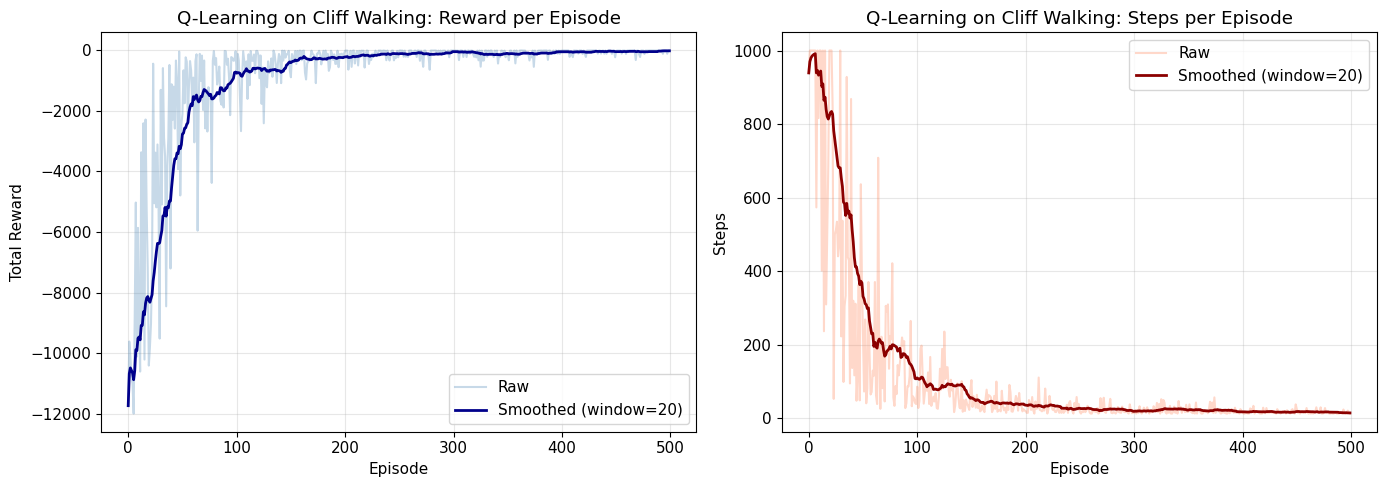

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages\fig1_learning_curves.png


In [7]:
# ============================================================
# 步骤 5：可视化 — 学习曲线
# Step 5: Visualization — Learning Curves
# ============================================================
# 绘制训练过程中的奖励和步数变化
# Plot reward and step count changes during training

print("\n" + "=" * 60)
print("Step 5: Learning Curves Visualization")
print("=" * 60)

# 使用滑动窗口平滑曲线
# Smooth curves with a rolling window
WINDOW_SIZE = 20


def rolling_mean(data, window):
    """计算滑动平均 / Compute rolling average."""
    return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]


smoothed_rewards = rolling_mean(episode_rewards, WINDOW_SIZE)
smoothed_steps = rolling_mean(episode_steps, WINDOW_SIZE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：每回合总奖励
# Left: total reward per episode
ax1.plot(episode_rewards, alpha=0.3, color='steelblue', label='Raw')
ax1.plot(smoothed_rewards, color='darkblue', linewidth=2, label=f'Smoothed (window={WINDOW_SIZE})')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Q-Learning on Cliff Walking: Reward per Episode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：每回合步数
# Right: steps per episode
ax2.plot(episode_steps, alpha=0.3, color='coral', label='Raw')
ax2.plot(smoothed_steps, color='darkred', linewidth=2, label=f'Smoothed (window={WINDOW_SIZE})')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Steps')
ax2.set_title('Q-Learning on Cliff Walking: Steps per Episode')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig1_learning_curves.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Step 6: Visualization — Learned Policy and Value Function


Step 6: Learned Policy and Value Function


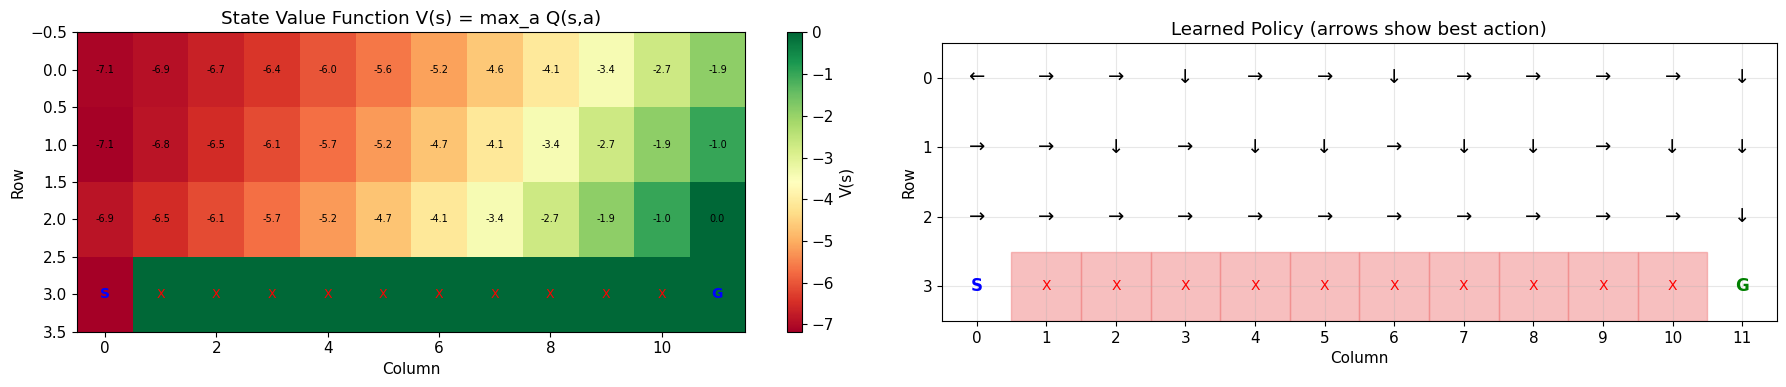

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages\fig2_policy_value.png

Learned Policy (text):
   0   1   2   3   4   5   6   7   8   9  10  11
0  ←   →   →   ↓   →   →   ↓   →   →   →   →   ↓
1  →   →   ↓   →   ↓   ↓   →   ↓   ↓   →   ↓   ↓
2  →   →   →   →   →   →   →   →   →   →   →   ↓
3  S   X   X   X   X   X   X   X   X   X   X   G


In [8]:
# ============================================================
# 步骤 6：可视化 — 学到的策略和价值函数
# Step 6: Visualization — Learned Policy and Value Function
# ============================================================
# 从 Q 表提取最优策略和状态价值函数
# Extract optimal policy and state value function from Q-table

print("\n" + "=" * 60)
print("Step 6: Learned Policy and Value Function")
print("=" * 60)

# 策略箭头符号
# Policy arrow symbols
ARROW_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

# 提取每个状态的最优动作和 V(s) = max_a Q(s,a)
# Extract optimal action and V(s) = max_a Q(s,a) for each state
policy_grid = np.zeros((CLIFF_ROWS, CLIFF_COLS), dtype=int)
value_grid = np.zeros((CLIFF_ROWS, CLIFF_COLS))

for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        idx = state_to_idx(r, c)
        policy_grid[r, c] = np.argmax(q_table[idx])
        value_grid[r, c] = np.max(q_table[idx])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

# 左图：价值函数热力图
# Left: Value function heatmap
im = ax1.imshow(value_grid, cmap='RdYlGn', aspect='auto')
ax1.set_title('State Value Function V(s) = max_a Q(s,a)')
ax1.set_xlabel('Column')
ax1.set_ylabel('Row')
plt.colorbar(im, ax=ax1, label='V(s)')

# 标注特殊位置
# Annotate special positions
for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        if (r, c) == CLIFF_START:
            ax1.text(c, r, 'S', ha='center', va='center', fontsize=10, fontweight='bold', color='blue')
        elif (r, c) == CLIFF_GOAL:
            ax1.text(c, r, 'G', ha='center', va='center', fontsize=10, fontweight='bold', color='blue')
        elif r == 3 and 1 <= c <= 10:
            ax1.text(c, r, 'X', ha='center', va='center', fontsize=9, color='red')
        else:
            ax1.text(c, r, f'{value_grid[r, c]:.1f}', ha='center', va='center', fontsize=7)

# 右图：学到的策略（箭头）
# Right: Learned policy (arrows)
ax2.set_xlim(-0.5, CLIFF_COLS - 0.5)
ax2.set_ylim(CLIFF_ROWS - 0.5, -0.5)
ax2.set_title('Learned Policy (arrows show best action)')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')
ax2.set_xticks(range(CLIFF_COLS))
ax2.set_yticks(range(CLIFF_ROWS))
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        if (r, c) == CLIFF_START:
            ax2.text(c, r, 'S', ha='center', va='center', fontsize=12, fontweight='bold', color='blue')
        elif (r, c) == CLIFF_GOAL:
            ax2.text(c, r, 'G', ha='center', va='center', fontsize=12, fontweight='bold', color='green')
        elif r == 3 and 1 <= c <= 10:
            ax2.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color='lightcoral', alpha=0.5))
            ax2.text(c, r, 'X', ha='center', va='center', fontsize=10, color='red')
        else:
            arrow = ARROW_SYMBOLS[policy_grid[r, c]]
            ax2.text(c, r, arrow, ha='center', va='center', fontsize=14)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig2_policy_value.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

# 打印文本版策略
# Print text version of policy
print("\nLearned Policy (text):")
print("  " + "  ".join(f"{c:>2}" for c in range(CLIFF_COLS)))
for r in range(CLIFF_ROWS):
    row_str = []
    for c in range(CLIFF_COLS):
        if (r, c) == CLIFF_START:
            row_str.append(' S')
        elif (r, c) == CLIFF_GOAL:
            row_str.append(' G')
        elif r == 3 and 1 <= c <= 10:
            row_str.append(' X')
        else:
            row_str.append(f' {ARROW_SYMBOLS[policy_grid[r, c]]}')
    print(f"{r} {'  '.join(row_str)}")

## Step 7: Exploration vs Exploitation — Epsilon Decay Comparison


Step 7: Exploration vs Exploitation Comparison
      High Explore (ε=0.3 fixed): last 30 avg reward = -161.6
          Decaying (ε: 1.0→0.01): last 30 avg reward = -20.5
      Low Explore (ε=0.01 fixed): last 30 avg reward = -14.2


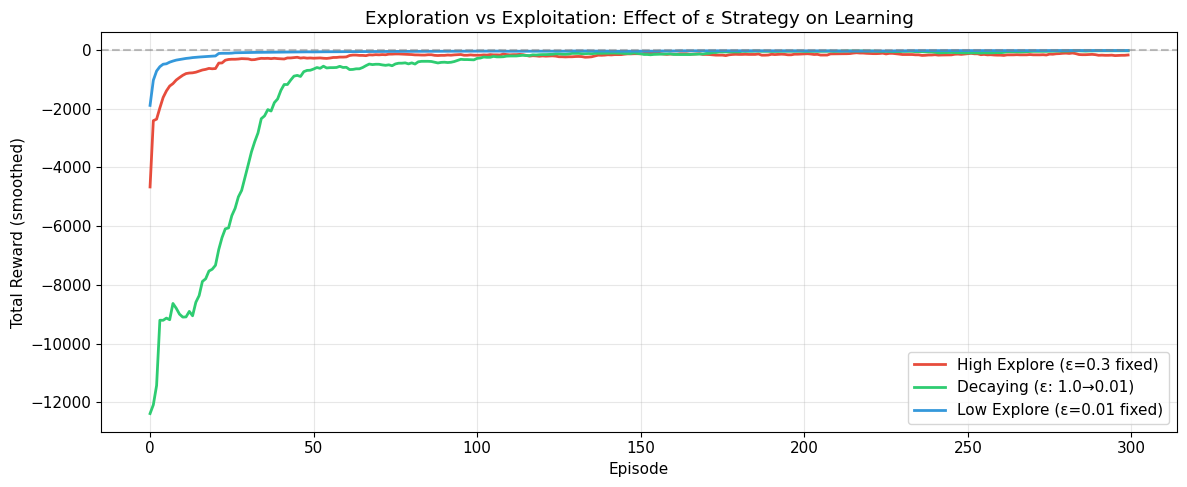

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages\fig3_explore_exploit.png


In [9]:
# ============================================================
# 步骤 7：探索 vs 利用 — Epsilon 衰减对比实验
# Step 7: Exploration vs Exploitation — Epsilon Decay Comparison
# ============================================================
# 对比不同 epsilon 衰减策略的学习效果
# Compare learning performance with different epsilon decay strategies
# 这直接对应 Slides 中的 Exploitation vs Exploration 子问题
# This directly corresponds to the Exploitation vs Exploration subproblem from Slides

print("\n" + "=" * 60)
print("Step 7: Exploration vs Exploitation Comparison")
print("=" * 60)

COMPARISON_EPISODES = 300

# 三种探索策略
# Three exploration strategies
strategies = {
    'High Explore (ε=0.3 fixed)': {'start': 0.3, 'decay': 1.0, 'min': 0.3},
    'Decaying (ε: 1.0→0.01)': {'start': 1.0, 'decay': 0.99, 'min': 0.01},
    'Low Explore (ε=0.01 fixed)': {'start': 0.01, 'decay': 1.0, 'min': 0.01},
}

results = {}

for name, params in strategies.items():
    # 每种策略独立训练
    # Train independently for each strategy
    q = np.zeros((NUM_CLIFF_STATES, NUM_CLIFF_ACTIONS))
    eps = params['start']
    rewards_log = []

    for ep in range(COMPARISON_EPISODES):
        s = state_to_idx(*CLIFF_START)
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < 1000:
            steps += 1
            if random.random() < eps:
                a = random.choice(range(NUM_CLIFF_ACTIONS))
            else:
                a = np.argmax(q[s])

            ns, r, done = cliff_step(s, a)
            ep_reward += r
            td = r + GAMMA * np.max(q[ns]) - q[s][a]
            q[s][a] += ALPHA * td
            s = ns

        rewards_log.append(ep_reward)
        eps = max(params['min'], eps * params['decay'])

    results[name] = rewards_log
    avg_last = np.mean(rewards_log[-30:])
    print(f"  {name:>30}: last 30 avg reward = {avg_last:.1f}")

# 绘制对比图
# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for (name, rewards_log), color in zip(results.items(), colors):
    smoothed = rolling_mean(rewards_log, WINDOW_SIZE)
    ax.plot(smoothed, label=name, color=color, linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (smoothed)')
ax.set_title('Exploration vs Exploitation: Effect of ε Strategy on Learning')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.axhline(y=-13, color='gray', linestyle='--', alpha=0.5, label='Optimal ≈ -13')

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig3_explore_exploit.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Step 8: Effect of Discount Factor γ


Step 8: Effect of Discount Factor gamma

Reward sequence: 19 steps of -1, then +10 at step 20

 Gamma |      G_0 | Interpretation
-------------------------------------------------------
  0.00 |    -1.00 | Myopic: only sees immediate -1
  0.50 |    -2.00 | Moderate: future +10 partially discounted
  0.90 |    -7.30 | Far-sighted: future +10 matters a lot
  0.99 |    -9.12 | Far-sighted: future +10 matters a lot
  1.00 |    -9.00 | No discounting: all rewards equal weight


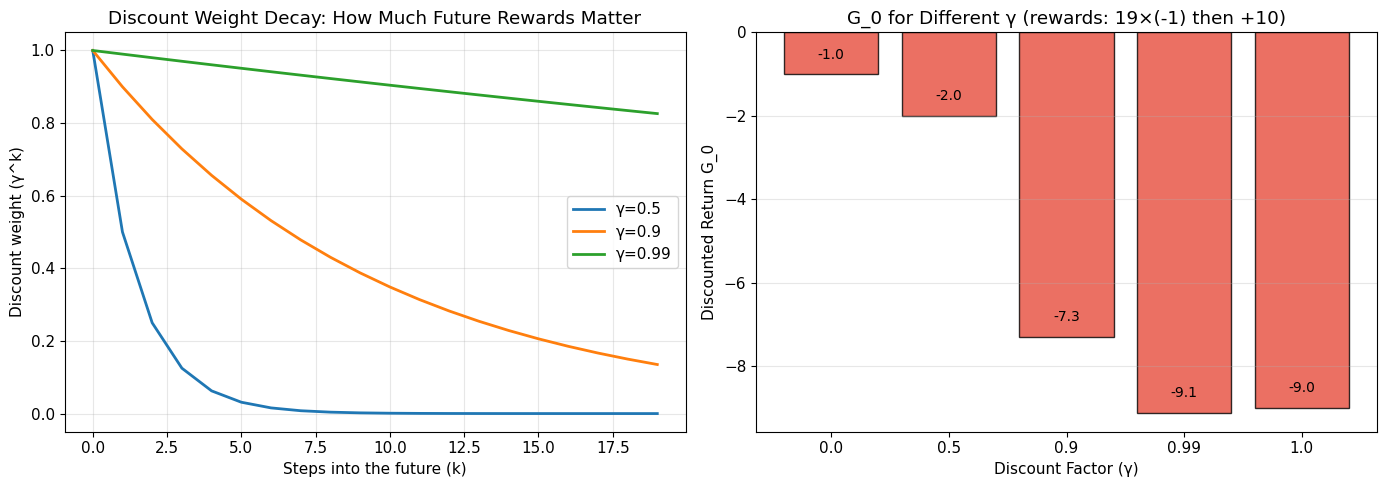

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages\fig4_discount_factor.png


In [10]:
# ============================================================
# 步骤 8：折扣因子 γ 的影响
# Step 8: Effect of Discount Factor γ
# ============================================================
# 演示不同 γ 值如何影响折扣回报 G_t
# Demonstrate how different γ values affect discounted return G_t
# 公式：G_t = r_{t+1} + γ r_{t+2} + γ² r_{t+3} + ...
# Formula: G_t = r_{t+1} + γ r_{t+2} + γ² r_{t+3} + ...

print("\n" + "=" * 60)
print("Step 8: Effect of Discount Factor gamma")
print("=" * 60)

# 模拟一个奖励序列：前面都是 -1，最后一步 +10
# Simulate a reward sequence: -1 for each step, +10 at the end
NUM_FUTURE_STEPS = 20
rewards_sequence = [-1] * (NUM_FUTURE_STEPS - 1) + [10]

gamma_values = [0.0, 0.5, 0.9, 0.99, 1.0]

print(f"\nReward sequence: {NUM_FUTURE_STEPS - 1} steps of -1, then +10 at step {NUM_FUTURE_STEPS}")
print(f"\n{'Gamma':>6} | {'G_0':>8} | Interpretation")
print("-" * 55)

gamma_returns = {}
for g in gamma_values:
    # G_0 = Σ γ^k * r_{k+1}
    g_return = sum(g ** k * rewards_sequence[k] for k in range(NUM_FUTURE_STEPS))
    gamma_returns[g] = g_return

    if g == 0.0:
        interp = "Myopic: only sees immediate -1"
    elif g == 1.0:
        interp = "No discounting: all rewards equal weight"
    elif g >= 0.9:
        interp = "Far-sighted: future +10 matters a lot"
    else:
        interp = "Moderate: future +10 partially discounted"
    print(f"{g:>6.2f} | {g_return:>8.2f} | {interp}")

# 绘制折扣权重衰减曲线
# Plot discount weight decay curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

steps_range = np.arange(NUM_FUTURE_STEPS)
for g in [0.5, 0.9, 0.99]:
    weights = [g ** k for k in steps_range]
    ax1.plot(steps_range, weights, label=f'γ={g}', linewidth=2)

ax1.set_xlabel('Steps into the future (k)')
ax1.set_ylabel('Discount weight (γ^k)')
ax1.set_title('Discount Weight Decay: How Much Future Rewards Matter')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：不同 γ 的 G_0 柱状图
# Right: bar chart of G_0 for different γ
bar_gammas = [str(g) for g in gamma_values]
bar_returns = [gamma_returns[g] for g in gamma_values]
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in bar_returns]

ax2.bar(bar_gammas, bar_returns, color=bar_colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Discount Factor (γ)')
ax2.set_ylabel('Discounted Return G_0')
ax2.set_title(f'G_0 for Different γ (rewards: {NUM_FUTURE_STEPS - 1}×(-1) then +10)')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# 在柱子上标注数值
# Annotate values on bars
for i, v in enumerate(bar_returns):
    ax2.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig4_discount_factor.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Step 9: RL Agent Taxonomy Overview


Step 9: RL Agent Taxonomy Overview


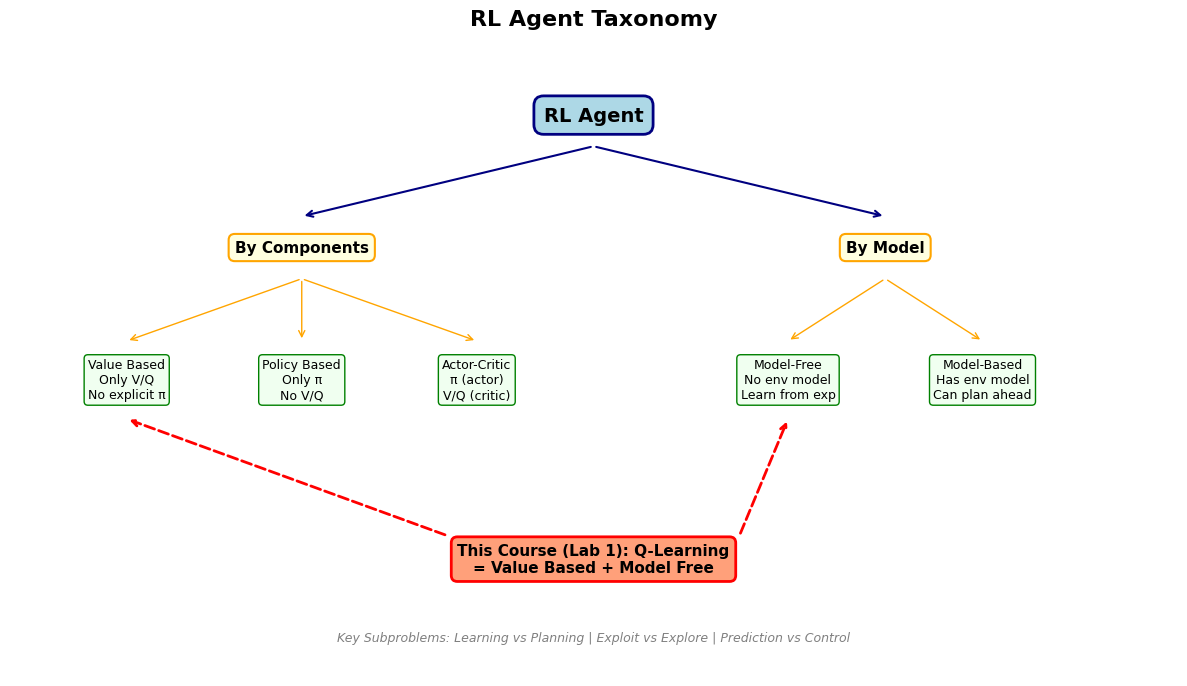

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages\fig5_agent_taxonomy.png

All visualizations saved to:
  C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week1_rl_intro_complete_demo_pages


In [11]:
# ============================================================
# 步骤 9：RL Agent 分类概览图
# Step 9: RL Agent Taxonomy Overview
# ============================================================
# 可视化 RL Agent 的分类体系
# Visualize the RL Agent taxonomy from Slides

print("\n" + "=" * 60)
print("Step 9: RL Agent Taxonomy Overview")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('RL Agent Taxonomy', fontsize=16, fontweight='bold', pad=20)

# 分类框样式
# Category box styles
box_style = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='navy', linewidth=2)
sub_style = dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='orange', linewidth=1.5)
leaf_style = dict(boxstyle='round,pad=0.3', facecolor='honeydew', edgecolor='green', linewidth=1)

# 顶层：RL Agent
# Top level: RL Agent
ax.text(6, 7.2, 'RL Agent', ha='center', va='center', fontsize=14, fontweight='bold', bbox=box_style)

# 第二层：按组件分类
# Second level: by components
ax.text(3, 5.5, 'By Components', ha='center', va='center', fontsize=11, fontweight='bold', bbox=sub_style)
ax.text(9, 5.5, 'By Model', ha='center', va='center', fontsize=11, fontweight='bold', bbox=sub_style)

# 连线
# Connecting lines
ax.annotate('', xy=(3, 5.9), xytext=(6, 6.8), arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
ax.annotate('', xy=(9, 5.9), xytext=(6, 6.8), arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))

# 第三层：具体类型
# Third level: specific types
# 按组件
ax.text(1.2, 3.8, 'Value Based\nOnly V/Q\nNo explicit π', ha='center', va='center', fontsize=9, bbox=leaf_style)
ax.text(3, 3.8, 'Policy Based\nOnly π\nNo V/Q', ha='center', va='center', fontsize=9, bbox=leaf_style)
ax.text(4.8, 3.8, 'Actor-Critic\nπ (actor)\nV/Q (critic)', ha='center', va='center', fontsize=9, bbox=leaf_style)

# 按模型
ax.text(8, 3.8, 'Model-Free\nNo env model\nLearn from exp', ha='center', va='center', fontsize=9, bbox=leaf_style)
ax.text(10, 3.8, 'Model-Based\nHas env model\nCan plan ahead', ha='center', va='center', fontsize=9, bbox=leaf_style)

# 连线到第三层
for x in [1.2, 3, 4.8]:
    ax.annotate('', xy=(x, 4.3), xytext=(3, 5.1), arrowprops=dict(arrowstyle='->', color='orange', lw=1))
for x in [8, 10]:
    ax.annotate('', xy=(x, 4.3), xytext=(9, 5.1), arrowprops=dict(arrowstyle='->', color='orange', lw=1))

# 底部：本课程使用的方法
# Bottom: method used in this course
highlight_style = dict(boxstyle='round,pad=0.4', facecolor='lightsalmon', edgecolor='red', linewidth=2)
ax.text(6, 1.5, 'This Course (Lab 1): Q-Learning\n= Value Based + Model Free', ha='center', va='center',
        fontsize=11, fontweight='bold', bbox=highlight_style)

ax.annotate('', xy=(1.2, 3.3), xytext=(4.5, 1.8), arrowprops=dict(arrowstyle='->', color='red', lw=2, ls='--'))
ax.annotate('', xy=(8, 3.3), xytext=(7.5, 1.8), arrowprops=dict(arrowstyle='->', color='red', lw=2, ls='--'))

# 底部注释
# Bottom note
ax.text(6, 0.5, 'Key Subproblems: Learning vs Planning | Exploit vs Explore | Prediction vs Control',
        ha='center', va='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig5_agent_taxonomy.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

print("\n" + "=" * 60)
print("All visualizations saved to:")
print(f"  {OUTPUT_DIR}")
print("=" * 60)